<a href="https://colab.research.google.com/github/juhsylvabb-ops/Olist_Analysis/blob/main/analise_exploratoria/olist_analise_completa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olist E-commerce — Análise Completa
### Tech Challenge · POSTECH DTAT · Fase 1



## CÉLULA 1 — Preparar arquivos

In [1]:
import shutil, zipfile, os, glob

os.makedirs('/content/olist', exist_ok=True)

# Descompacta todos os ZIPs
for arquivo in glob.glob('/content/*.zip'):
    with zipfile.ZipFile(arquivo, 'r') as z:
        z.extractall('/content/olist')
    print(f'Extraido: {os.path.basename(arquivo)}')

# Copia CSVs soltos
for arquivo in glob.glob('/content/*.csv'):
    nome = os.path.basename(arquivo)
    destino = f'/content/olist/{nome}'
    if not os.path.exists(destino):
        shutil.copy(arquivo, destino)
        print(f'Copiado: {nome}')

arquivos = [f for f in os.listdir('/content/olist') if f.endswith('.csv')]
print(f'\nTotal de arquivos: {len(arquivos)}')
for f in sorted(arquivos):
    print(f'  {f}')

Extraido: olist_order_reviews_dataset.csv.zip
Extraido: olist_geolocation_dataset.csv.zip
Extraido: olist_order_payments_dataset.csv.zip
Extraido: olist_order_items_dataset.csv.zip
Extraido: olist_customers_dataset.csv.zip
Extraido: olist_products_dataset.csv.zip
Extraido: olist_orders_dataset.csv.zip
Copiado: olist_sellers_dataset.csv
Copiado: product_category_name_translation.csv

Total de arquivos: 9
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_orders_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv


## CÉLULA 2 — Importar bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Paleta de cores Olist
AZUL      = '#2255E8'
AZUL_DARK = '#131D4F'
VERDE     = '#6B8C3E'
MENTA     = '#8ECFC9'
VERMELHO  = '#E8451E'
ROSA      = '#F0A0C0'
LARANJA   = '#F5A623'

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
print('Bibliotecas importadas!')

Bibliotecas importadas!


## CÉLULA 3 — Carregar os dados

In [3]:
CAMINHO = '/content/olist/'

clientes   = pd.read_csv(CAMINHO + 'olist_customers_dataset.csv')
pedidos    = pd.read_csv(CAMINHO + 'olist_orders_dataset.csv')
itens      = pd.read_csv(CAMINHO + 'olist_order_items_dataset.csv')
pagamentos = pd.read_csv(CAMINHO + 'olist_order_payments_dataset.csv')
reviews    = pd.read_csv(CAMINHO + 'olist_order_reviews_dataset.csv')
produtos   = pd.read_csv(CAMINHO + 'olist_products_dataset.csv')
vendedores = pd.read_csv(CAMINHO + 'olist_sellers_dataset.csv')
geo        = pd.read_csv(CAMINHO + 'olist_geolocation_dataset.csv')
categorias = pd.read_csv(CAMINHO + 'product_category_name_translation.csv')

tabelas = {
    'clientes': clientes, 'pedidos': pedidos, 'itens': itens,
    'pagamentos': pagamentos, 'reviews': reviews, 'produtos': produtos,
    'vendedores': vendedores, 'geo': geo, 'categorias': categorias
}
for nome, df in tabelas.items():
    print(f'{nome:12s}: {df.shape[0]:>8,} linhas x {df.shape[1]} colunas')

clientes    :   99,441 linhas x 5 colunas
pedidos     :   99,441 linhas x 8 colunas
itens       :  112,650 linhas x 7 colunas
pagamentos  :  103,886 linhas x 5 colunas
reviews     :   99,224 linhas x 7 colunas
produtos    :   32,951 linhas x 9 colunas
vendedores  :    3,095 linhas x 4 colunas
geo         : 1,000,163 linhas x 5 colunas
categorias  :       71 linhas x 2 colunas


## CÉLULA 4 — Limpeza dos dados

In [4]:
# Converter datas
cols_data = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in cols_data:
    pedidos[col] = pd.to_datetime(pedidos[col])

reviews['review_creation_date']    = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

# Preencher categoria nula
produtos['product_category_name'] = produtos['product_category_name'].fillna('sem_categoria')

# Deduplicar geolocalização
geo_unico = geo.drop_duplicates(subset='geolocation_zip_code_prefix')

print('Limpeza concluida!')
print(f'  Datas convertidas: {len(cols_data)} colunas')
print(f'  Nulos em categoria: {produtos["product_category_name"].isnull().sum()}')
print(f'  Geo apos deduplicar: {len(geo_unico):,} registros')

Limpeza concluida!
  Datas convertidas: 5 colunas
  Nulos em categoria: 0
  Geo apos deduplicar: 19,015 registros


## CÉLULA 5 — Montar base unificada

In [5]:
base = (
    itens
    .merge(pedidos,    on='order_id',             how='left')
    .merge(clientes,   on='customer_id',           how='left')
    .merge(produtos,   on='product_id',            how='left')
    .merge(categorias, on='product_category_name', how='left')
    .merge(vendedores, on='seller_id',             how='left')
    .merge(pagamentos, on='order_id',              how='left')
    .merge(reviews[['order_id','review_score','review_comment_title',
                    'review_comment_message']], on='order_id', how='left')
    .merge(geo_unico.rename(columns={
               'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
               'geolocation_lat': 'customer_lat',
               'geolocation_lng': 'customer_lng'})
           [['customer_zip_code_prefix','customer_lat','customer_lng']],
           on='customer_zip_code_prefix', how='left')
)

print(f'Base unificada criada!')
print(f'  Linhas  : {len(base):,}')
print(f'  Colunas : {base.shape[1]}')
print(f'  Colunas : {list(base.columns)}')

Base unificada criada!
  Linhas  : 118,310
  Colunas : 39
  Colunas : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_score', 'review_comment_title', 'review_comment_message', 'customer_lat', 'customer_lng']


## CÉLULA 6 — Validação da base

In [6]:
print('VALIDACAO COMPLETA DA BASE')
print('=' * 55)

checks = [
    ('Pedidos unicos',    pedidos['order_id'].nunique(),     base['order_id'].nunique()),
    ('Clientes unicos',   clientes['customer_id'].nunique(), base['customer_id'].nunique()),
    ('Produtos unicos',   produtos['product_id'].nunique(),  base['product_id'].nunique()),
    ('Vendedores unicos', vendedores['seller_id'].nunique(), base['seller_id'].nunique()),
]
for nome, original, na_base in checks:
    ok = 'OK' if original >= na_base else 'DIVERGENCIA'
    print(f'[{ok}]  {nome:22s}: original={original:,}  |  base={na_base:,}')

print(f'\nLINHAS')
print('=' * 55)
print(f'  itens (base do merge)    : {len(itens):,}')
print(f'  + linhas multi-pagamento : +{len(base) - len(itens):,}')
print(f'  = base final             : {len(base):,}')

print(f'\nNULOS NAS COLUNAS CRITICAS')
print('=' * 55)
cols_criticas = ['order_id','customer_id','product_id','seller_id',
                 'price','payment_value','review_score','customer_state']
for col in cols_criticas:
    nulos = base[col].isnull().sum()
    pct   = nulos / len(base) * 100
    status = 'OK' if nulos == 0 else f'NULOS: {nulos:,} ({pct:.1f}%)'
    print(f'  {col:35s}: {status}')

base['order_purchase_timestamp'] = pd.to_datetime(base['order_purchase_timestamp'])
print(f'\nPERIODO DOS DADOS')
print('=' * 55)
print(f'  De : {base["order_purchase_timestamp"].min().date()}')
print(f'  Ate: {base["order_purchase_timestamp"].max().date()}')

VALIDACAO COMPLETA DA BASE
[OK]  Pedidos unicos        : original=99,441  |  base=98,666
[OK]  Clientes unicos       : original=99,441  |  base=98,666
[OK]  Produtos unicos       : original=32,951  |  base=32,951
[OK]  Vendedores unicos     : original=3,095  |  base=3,095

LINHAS
  itens (base do merge)    : 112,650
  + linhas multi-pagamento : +5,660
  = base final             : 118,310

NULOS NAS COLUNAS CRITICAS
  order_id                           : OK
  customer_id                        : OK
  product_id                         : OK
  seller_id                          : OK
  price                              : OK
  payment_value                      : NULOS: 3 (0.0%)
  review_score                       : NULOS: 978 (0.8%)
  customer_state                     : OK

PERIODO DOS DADOS
  De : 2016-09-04
  Ate: 2018-09-03


---
## VISÃO MACRO

## CÉLULA 7 — KPIs gerais

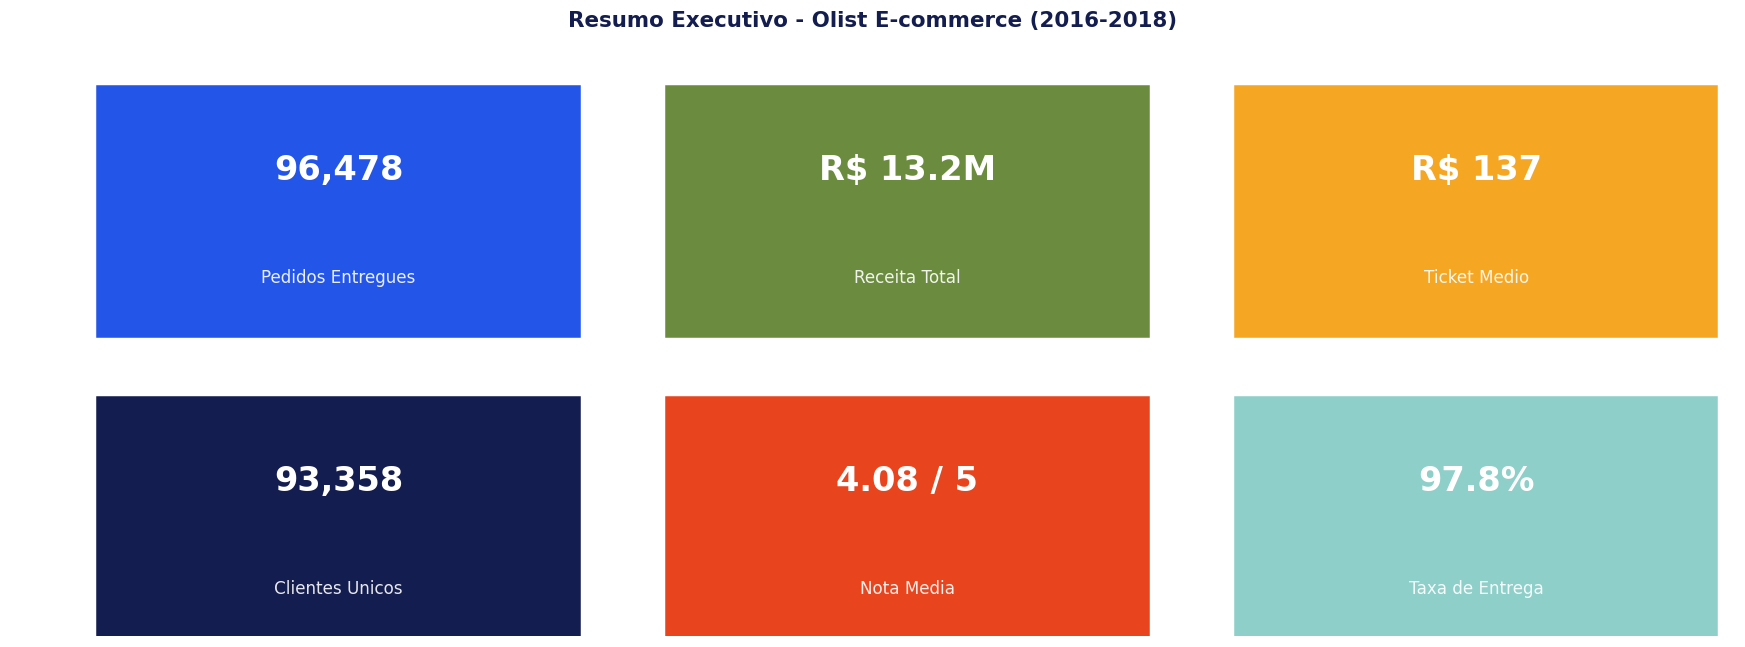

In [7]:
entregues = base[base['order_status'] == 'delivered']

total_pedidos   = entregues['order_id'].nunique()
receita_total   = entregues.drop_duplicates(subset=['order_id','order_item_id'])['price'].sum()
clientes_unicos = entregues['customer_unique_id'].nunique()
ticket_medio    = receita_total / total_pedidos
nota_media      = entregues['review_score'].mean()
taxa_entrega    = (base['order_status'] == 'delivered').mean() * 100

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')

kpis = [
    ('Pedidos Entregues', f'{total_pedidos:,}',           AZUL),
    ('Receita Total',     f'R$ {receita_total/1e6:.1f}M', VERDE),
    ('Ticket Medio',      f'R$ {ticket_medio:.0f}',       LARANJA),
    ('Clientes Unicos',   f'{clientes_unicos:,}',          AZUL_DARK),
    ('Nota Media',        f'{nota_media:.2f} / 5',        VERMELHO),
    ('Taxa de Entrega',   f'{taxa_entrega:.1f}%',          MENTA[0:7]),
]

cols = 3
for i, (titulo, valor, cor) in enumerate(kpis):
    col = i % cols
    row = i // cols
    x = 0.05 + col * 0.33
    y = 0.50 - row * 0.52
    rect = plt.Rectangle((x, y), 0.28, 0.42, transform=ax.transAxes, color=cor, zorder=1)
    ax.add_patch(rect)
    ax.text(x+0.14, y+0.28, valor, transform=ax.transAxes,
            ha='center', va='center', fontsize=22, fontweight='bold', color='white', zorder=2)
    ax.text(x+0.14, y+0.10, titulo, transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color='white', alpha=0.9, zorder=2)

ax.text(0.5, 1.02, 'Resumo Executivo - Olist E-commerce (2016-2018)',
        transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold', color=AZUL_DARK)
plt.tight_layout()
plt.show()

## CÉLULA 8 — Faturamento mensal

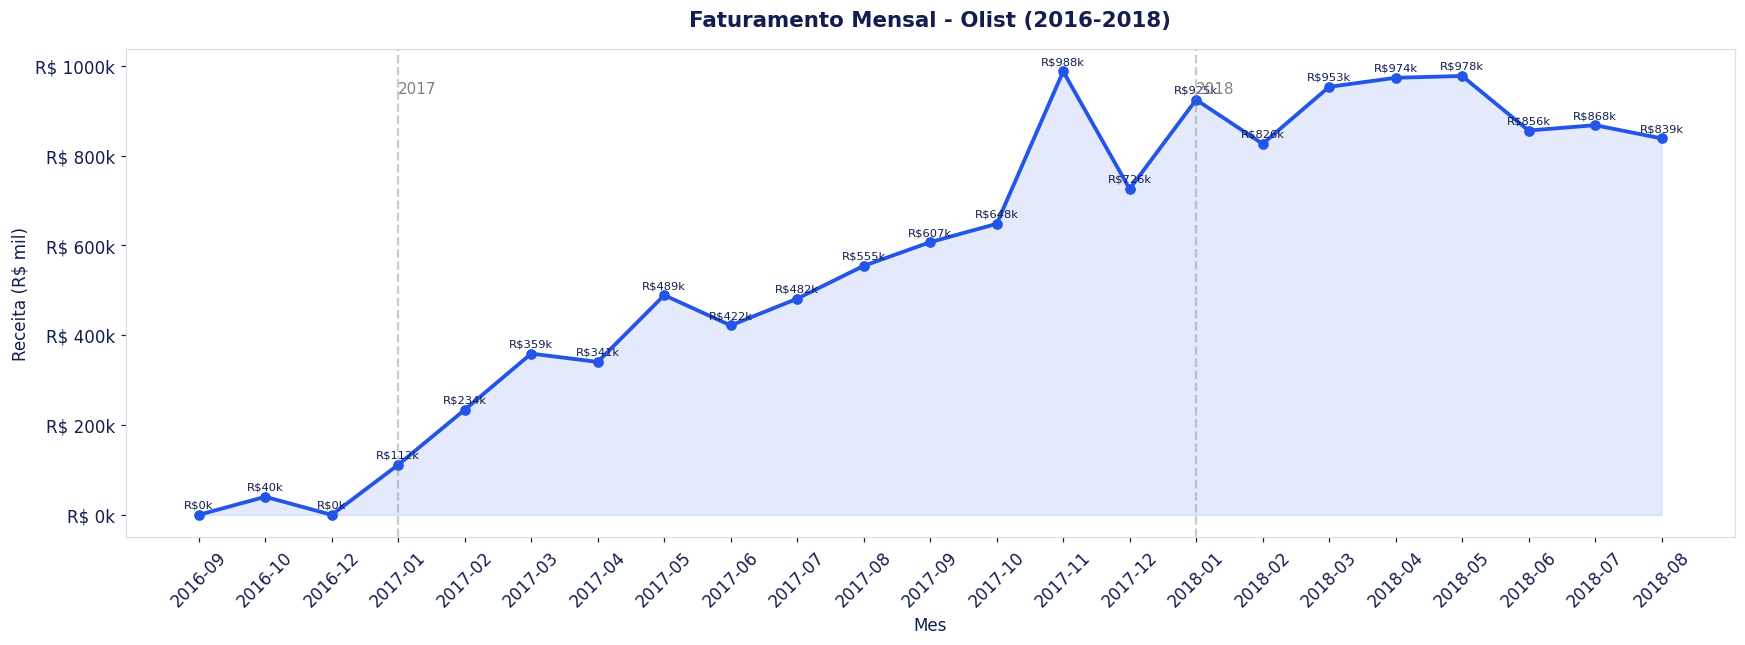

In [8]:
entregues_items = entregues.drop_duplicates(subset=['order_id', 'order_item_id']).copy()
entregues_items['ano_mes'] = entregues_items['order_purchase_timestamp'].dt.to_period('M')

mensal = (
    entregues_items.groupby('ano_mes')['price']
    .sum().reset_index().sort_values('ano_mes')
)
mensal['ano_mes_str'] = mensal['ano_mes'].astype(str)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(mensal['ano_mes_str'], mensal['price']/1000,
        color=AZUL, linewidth=2.5, marker='o', markersize=6)
ax.fill_between(mensal['ano_mes_str'], mensal['price']/1000, alpha=0.12, color=AZUL)

for _, row in mensal.iterrows():
    ax.text(row['ano_mes_str'], row['price']/1000 + 15,
            f"R${row['price']/1000:.0f}k", ha='center', fontsize=7.5, color=AZUL_DARK)

for mes in mensal['ano_mes_str']:
    if mes.endswith('-01'):
        ax.axvline(x=mes, color='gray', linestyle='--', alpha=0.4)
        ax.text(mes, mensal['price'].max()/1000*0.95, mes[:4],
                color='gray', fontsize=10, ha='left')

ax.set_title('Faturamento Mensal - Olist (2016-2018)',
             fontsize=14, fontweight='bold', color=AZUL_DARK, pad=15)
ax.set_xlabel('Mes', color=AZUL_DARK)
ax.set_ylabel('Receita (R$ mil)', color=AZUL_DARK)
ax.tick_params(colors=AZUL_DARK)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'R$ {v:.0f}k'))
for spine in ax.spines.values():
    spine.set_edgecolor('#ddd')
plt.tight_layout()
plt.show()

# CÉLULA 9 - Top 10 Produtos mais vendidos

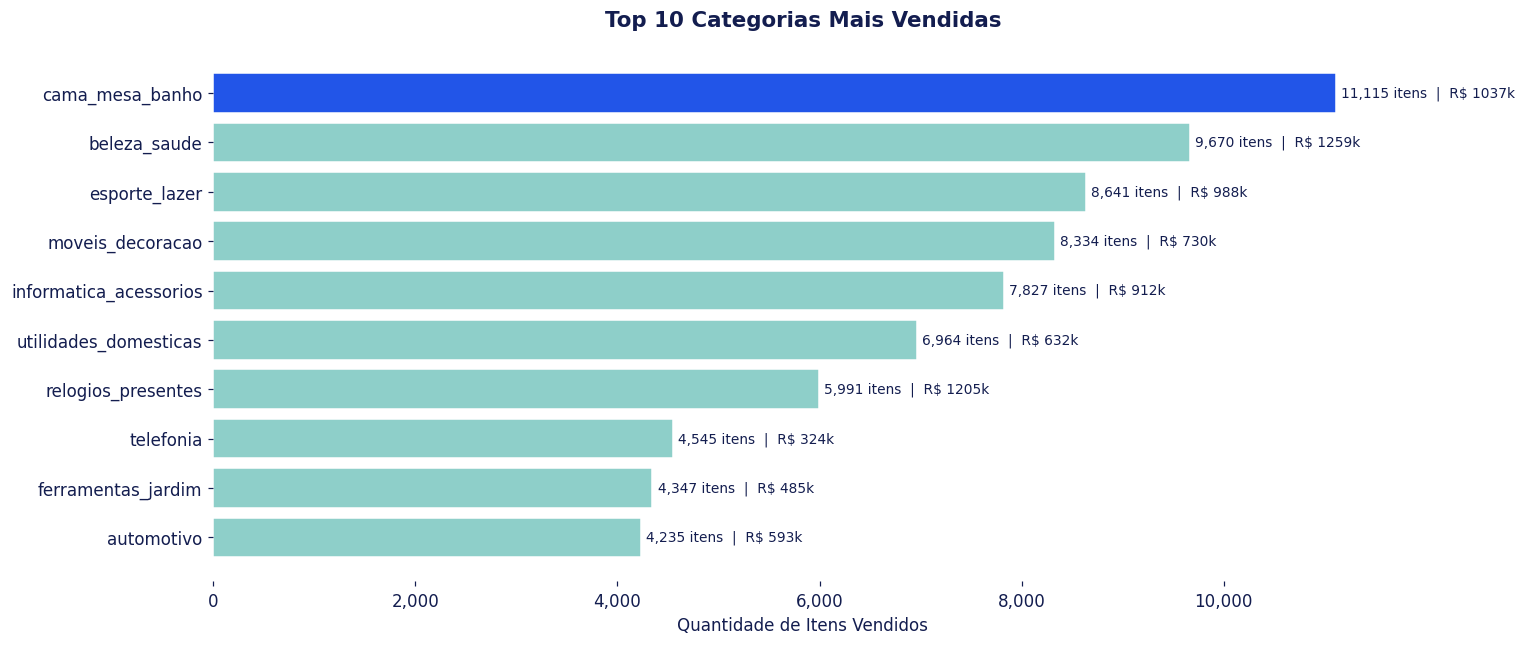

In [9]:
# No dataset Olist os produtos são anonimizados (só tem ID)
# então agrupamos por categoria, que é a visão mais útil

top10 = (
    base.drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('product_category_name')
    .agg(
        qtd_vendida = ('order_item_id', 'count'),
        receita     = ('price', 'sum')
    )
    .reset_index()
    .sort_values('qtd_vendida', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

top10_ord = top10.sort_values('qtd_vendida', ascending=True)
cores = [AZUL if i == 9 else MENTA for i in range(10)]

bars = ax.barh(top10_ord['product_category_name'],
               top10_ord['qtd_vendida'],
               color=cores, edgecolor='white')

for bar, (_, row) in zip(bars, top10_ord.iterrows()):
    ax.text(bar.get_width() + 50,
            bar.get_y() + bar.get_height() / 2,
            f"{row['qtd_vendida']:,} itens  |  R$ {row['receita']/1e3:.0f}k",
            va='center', fontsize=9, color=AZUL_DARK)

ax.set_title('Top 10 Categorias Mais Vendidas', fontsize=14,
             fontweight='bold', color=AZUL_DARK, pad=15)
ax.set_xlabel('Quantidade de Itens Vendidos', color=AZUL_DARK)
ax.tick_params(colors=AZUL_DARK)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

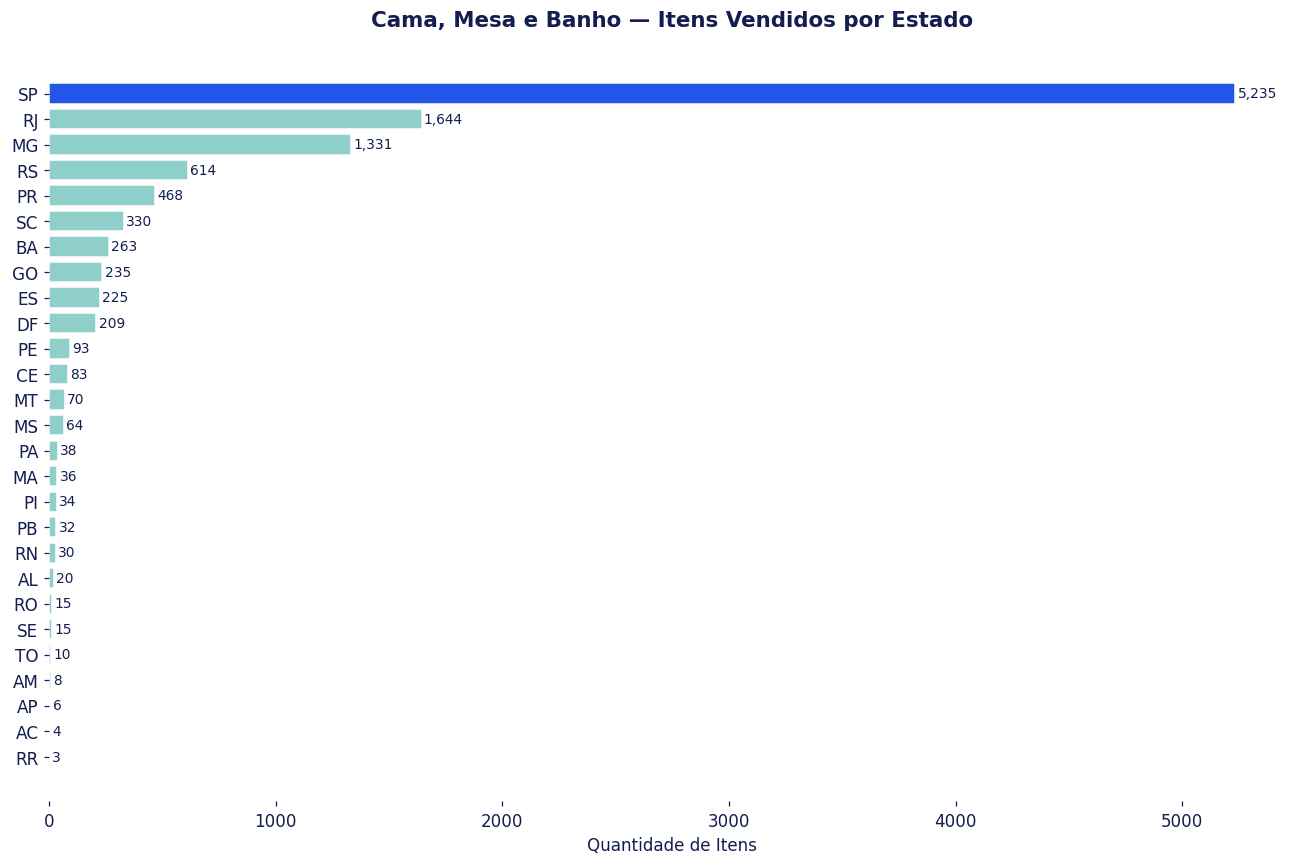


Total de itens vendidos: 11,115
Total de estados: 27


In [10]:
bed_bath = (
    base[base['product_category_name_english'] == 'bed_bath_table']  # filtro em inglês
    .drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('customer_state')['order_item_id']
    .count()
    .reset_index()
    .sort_values('order_item_id', ascending=True)
    .rename(columns={'order_item_id': 'qtd_itens'})
)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

cores = [AZUL if s == bed_bath['customer_state'].iloc[-1] else MENTA
         for s in bed_bath['customer_state']]

bars = ax.barh(bed_bath['customer_state'], bed_bath['qtd_itens'],
               color=cores, edgecolor='white')

for bar, (_, row) in zip(bars, bed_bath.iterrows()):
    ax.text(bar.get_width() + 10,
            bar.get_y() + bar.get_height() / 2,
            f"{row['qtd_itens']:,}",
            va='center', fontsize=9, color=AZUL_DARK)

ax.set_title('Cama, Mesa e Banho — Itens Vendidos por Estado',
             fontsize=14, fontweight='bold', color=AZUL_DARK, pad=15)
ax.set_xlabel('Quantidade de Itens', color=AZUL_DARK)
ax.tick_params(colors=AZUL_DARK)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nTotal de itens vendidos: {bed_bath['qtd_itens'].sum():,}")
print(f"Total de estados: {len(bed_bath)}")

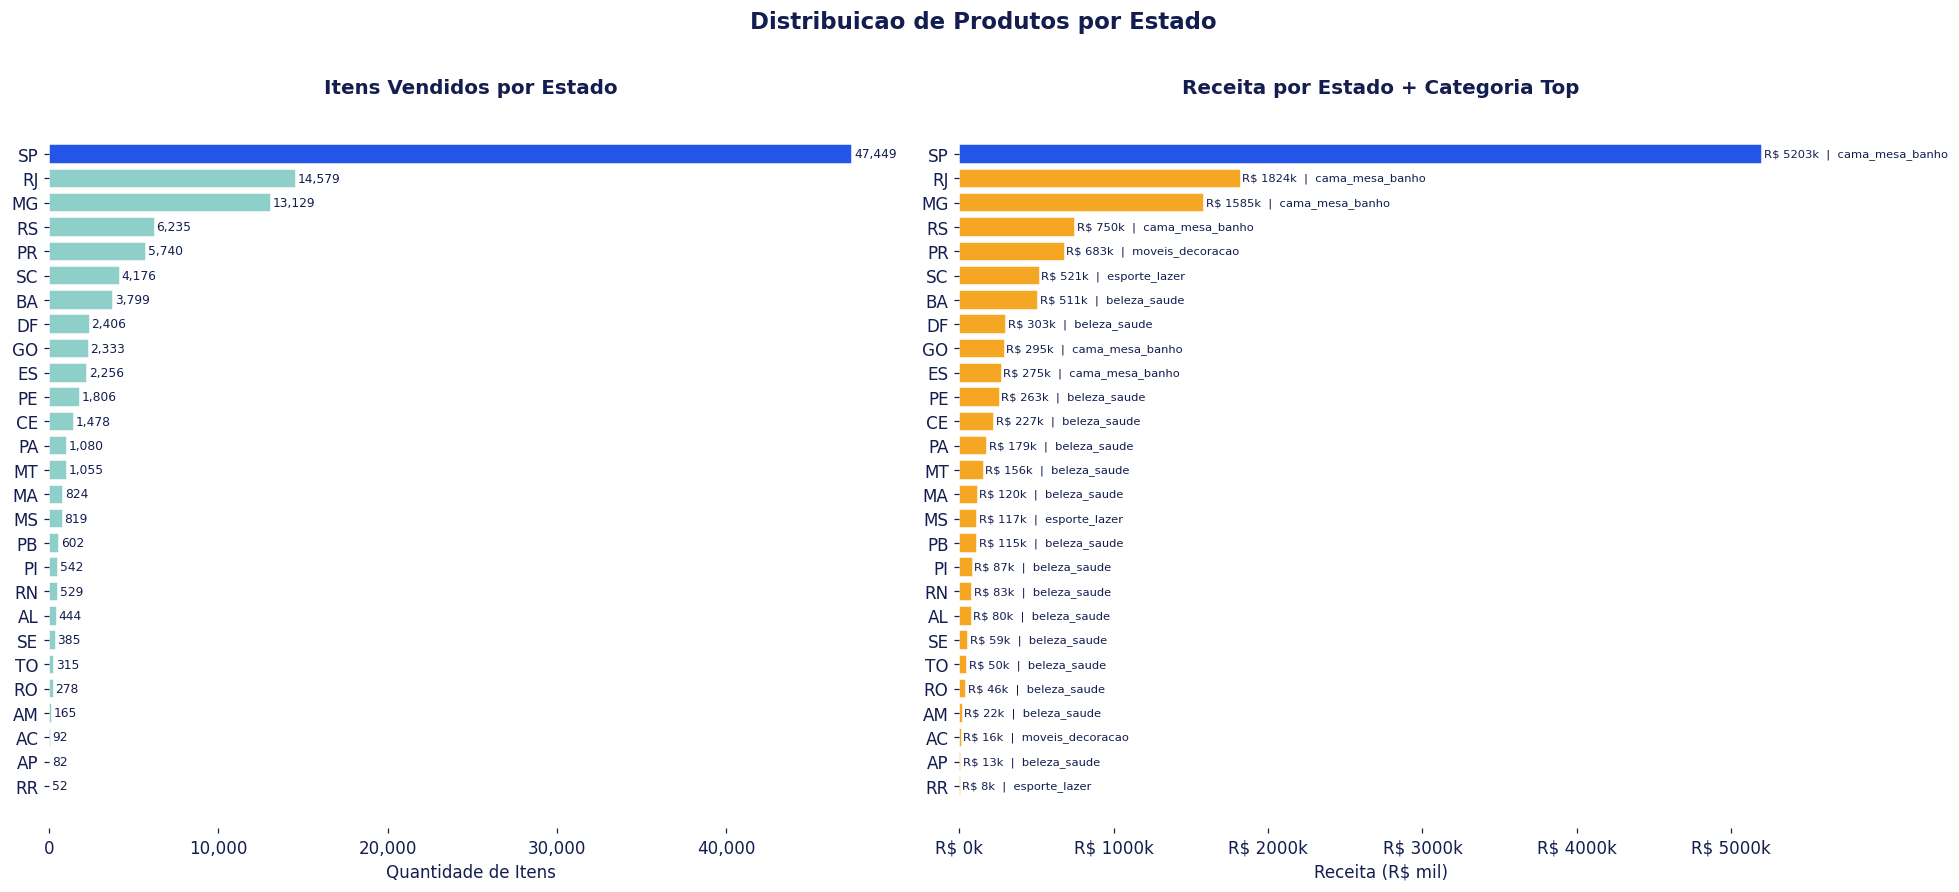


TOP 10 ESTADOS
  SP  |  47,449 itens  |  R$  5,202,955  |  cama_mesa_banho
  RJ  |  14,579 itens  |  R$  1,824,093  |  cama_mesa_banho
  MG  |  13,129 itens  |  R$  1,585,308  |  cama_mesa_banho
  RS  |   6,235 itens  |  R$    750,304  |  cama_mesa_banho
  PR  |   5,740 itens  |  R$    683,084  |  moveis_decoracao
  SC  |   4,176 itens  |  R$    520,553  |  esporte_lazer
  BA  |   3,799 itens  |  R$    511,350  |  beleza_saude
  DF  |   2,406 itens  |  R$    302,604  |  beleza_saude
  GO  |   2,333 itens  |  R$    294,592  |  cama_mesa_banho
  ES  |   2,256 itens  |  R$    275,037  |  cama_mesa_banho


In [11]:
# Itens vendidos por estado
por_estado = (
    base.drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('customer_state')
    .agg(
        qtd_itens = ('order_item_id', 'count'),
        receita   = ('price', 'sum'),
        top_cat   = ('product_category_name',
                     lambda x: x.value_counts().index[0] if len(x.dropna()) > 0 else 'N/A')
    )
    .reset_index()
    .sort_values('qtd_itens', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('white')

# --- Gráfico 1: Itens por estado ---
ax = axes[0]
ax.set_facecolor('white')
ord1 = por_estado.sort_values('qtd_itens', ascending=True)
cores = [AZUL if s == 'SP' else MENTA for s in ord1['customer_state']]

bars = ax.barh(ord1['customer_state'], ord1['qtd_itens'],
               color=cores, edgecolor='white')
for bar, (_, row) in zip(bars, ord1.iterrows()):
    ax.text(bar.get_width() + 100,
            bar.get_y() + bar.get_height() / 2,
            f"{row['qtd_itens']:,}",
            va='center', fontsize=8, color=AZUL_DARK)

ax.set_title('Itens Vendidos por Estado', fontsize=13,
             fontweight='bold', color=AZUL_DARK, pad=12)
ax.set_xlabel('Quantidade de Itens', color=AZUL_DARK)
ax.tick_params(colors=AZUL_DARK)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Gráfico 2: Receita por estado ---
ax2 = axes[1]
ax2.set_facecolor('white')
ord2 = por_estado.sort_values('receita', ascending=True)
cores2 = [AZUL if s == 'SP' else LARANJA for s in ord2['customer_state']]

bars2 = ax2.barh(ord2['customer_state'], ord2['receita'] / 1e3,
                 color=cores2, edgecolor='white')
for bar, (_, row) in zip(bars2, ord2.iterrows()):
    ax2.text(bar.get_width() + 10,
             bar.get_y() + bar.get_height() / 2,
             f"R$ {row['receita']/1e3:.0f}k  |  {row['top_cat']}",
             va='center', fontsize=7.5, color=AZUL_DARK)

ax2.set_title('Receita por Estado + Categoria Top', fontsize=13,
              fontweight='bold', color=AZUL_DARK, pad=12)
ax2.set_xlabel('Receita (R$ mil)', color=AZUL_DARK)
ax2.tick_params(colors=AZUL_DARK)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'R$ {v:.0f}k'))
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.suptitle('Distribuicao de Produtos por Estado',
             fontsize=15, fontweight='bold', color=AZUL_DARK, y=1.01)
plt.tight_layout()
plt.show()

# Tabela resumo
print("\nTOP 10 ESTADOS")
print("=" * 65)
for _, row in por_estado.head(10).iterrows():
    print(f"  {row['customer_state']}  |  {row['qtd_itens']:>6,} itens  |  "
          f"R$ {row['receita']:>10,.0f}  |  {row['top_cat']}")

In [12]:
ticket_produto = (
    base.drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('product_category_name')
    .agg(
        qtd_itens      = ('order_item_id',    'count'),
        receita_produto = ('price',           'sum'),
        receita_frete  = ('freight_value',    'sum'),
        ticket_medio   = ('price',            'mean'),
        frete_medio    = ('freight_value',    'mean')
    )
    .reset_index()
    .sort_values('ticket_medio', ascending=False)
    .reset_index(drop=True)
)

ticket_produto['receita_total'] = (
    ticket_produto['receita_produto'] + ticket_produto['receita_frete']
)
ticket_produto['pct_frete'] = (
    ticket_produto['receita_frete'] / ticket_produto['receita_total'] * 100
)

fmt = ticket_produto.copy()
fmt['qtd_itens']       = fmt['qtd_itens'].apply(lambda x: f'{x:,}')
fmt['receita_produto'] = fmt['receita_produto'].apply(lambda x: f'R$ {x:,.0f}')
fmt['receita_frete']   = fmt['receita_frete'].apply(lambda x: f'R$ {x:,.0f}')
fmt['receita_total']   = fmt['receita_total'].apply(lambda x: f'R$ {x:,.0f}')
fmt['ticket_medio']    = fmt['ticket_medio'].apply(lambda x: f'R$ {x:.2f}')
fmt['frete_medio']     = fmt['frete_medio'].apply(lambda x: f'R$ {x:.2f}')
fmt['pct_frete']       = fmt['pct_frete'].apply(lambda x: f'{x:.1f}%')

fmt.columns = ['Categoria', 'Qtd Itens', 'Receita Produto',
               'Receita Frete', 'Ticket Medio', 'Frete Medio',
               'Receita Total', '% Frete']

display(fmt)
print(f"\nTotal de categorias: {len(fmt)}")

,Categoria,Qtd Itens,Receita Produto,Receita Frete,Ticket Medio,Frete Medio,Receita Total,% Frete
0,pcs,203,"R$ 222,963","R$ 9,836",R$ 1098.34,R$ 48.45,"R$ 232,799",4.2%
1,portateis_casa_forno_e_cafe,76,"R$ 47,446","R$ 2,748",R$ 624.29,R$ 36.16,"R$ 50,194",5.5%
2,eletrodomesticos_2,238,"R$ 113,318","R$ 10,600",R$ 476.12,R$ 44.54,"R$ 123,918",8.6%
3,agro_industria_e_comercio,212,"R$ 72,530","R$ 5,844",R$ 342.12,R$ 27.56,"R$ 78,374",7.5%
4,instrumentos_musicais,680,"R$ 191,499","R$ 18,638",R$ 281.62,R$ 27.41,"R$ 210,137",8.9%
...,...,...,...,...,...,...,...,...
69,alimentos_bebidas,278,"R$ 15,179","R$ 4,508",R$ 54.60,R$ 16.22,"R$ 19,687",22.9%
70,cds_dvds_musicais,14,R$ 730,R$ 225,R$ 52.14,R$ 16.07,R$ 955,23.6%
71,fraldas_higiene,39,"R$ 1,568",R$ 574,R$ 40.19,R$ 14.71,"R$ 2,141",26.8%
72,flores,33,"R$ 1,110",R$ 489,R$ 33.64,R$ 14.81,"R$ 1,599",30.6%



Total de categorias: 74


In [13]:
ranking_ticket = (
    base.drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('product_category_name_english')
    .agg(
        qtd_itens    = ('order_item_id', 'count'),
        ticket_medio = ('price',         'mean'),
        receita      = ('price',         'sum')
    )
    .reset_index()
    .sort_values('ticket_medio', ascending=False)
    .reset_index(drop=True)
)

ranking_ticket.index += 1  # ranking começa em 1

fmt = ranking_ticket.copy()
fmt['ticket_medio'] = fmt['ticket_medio'].apply(lambda x: f'R$ {x:.2f}')
fmt['receita']      = fmt['receita'].apply(lambda x: f'R$ {x:,.0f}')
fmt['qtd_itens']    = fmt['qtd_itens'].apply(lambda x: f'{x:,}')

fmt.columns = ['Categoria', 'Qtd Itens', 'Ticket Medio', 'Receita Total']

pd.set_option('display.max_rows', None)
display(fmt)
pd.set_option('display.max_rows', 10)

,Categoria,Qtd Itens,Ticket Medio,Receita Total
1,computers,203,R$ 1098.34,"R$ 222,963"
2,small_appliances_home_oven_and_coffee,76,R$ 624.29,"R$ 47,446"
3,home_appliances_2,238,R$ 476.12,"R$ 113,318"
4,agro_industry_and_commerce,212,R$ 342.12,"R$ 72,530"
5,musical_instruments,680,R$ 281.62,"R$ 191,499"
6,small_appliances,679,R$ 280.78,"R$ 190,649"
7,fixed_telephony,264,R$ 225.69,"R$ 59,583"
8,construction_tools_safety,194,R$ 208.99,"R$ 40,545"
9,watches_gifts,"5,991",R$ 201.14,"R$ 1,205,006"
10,air_conditioning,297,R$ 185.27,"R$ 55,025"


In [14]:
fotos_completo = (
    produtos.groupby('product_category_name')
    .agg(
        qtd_produtos  = ('product_id',        'count'),
        media_fotos   = ('product_photos_qty', 'mean'),
        total_fotos   = ('product_photos_qty', 'sum')
    )
    .reset_index()
    .sort_values('media_fotos', ascending=False)
    .reset_index(drop=True)
)

fmt = fotos_completo.copy()
fmt['qtd_produtos'] = fmt['qtd_produtos'].apply(lambda x: f'{x:,}')
fmt['media_fotos']  = fmt['media_fotos'].apply(lambda x: f'{x:.1f}')
fmt['total_fotos']  = fmt['total_fotos'].apply(lambda x: f'{x:,.0f}')

fmt.columns = ['Categoria', 'Qtd Produtos', 'Media Fotos', 'Total Fotos']

pd.set_option('display.max_rows', None)
display(fmt)
pd.set_option('display.max_rows', 10)
print(f"\nTotal de categorias: {len(fmt)}")

,Categoria,Qtd Produtos,Media Fotos,Total Fotos
0,fashion_calcados,173,5.1,886
1,pc_gamer,3,4.3,13
2,casa_construcao,225,3.3,735
3,fashion_underwear_e_moda_praia,53,3.3,173
4,fashion_roupa_infanto_juvenil,5,3.2,16
5,tablets_impressao_imagem,9,3.0,27
6,artes_e_artesanato,19,3.0,57
7,telefonia_fixa,116,3.0,347
8,fashion_bolsas_e_acessorios,849,2.9,"2,497"
9,instrumentos_musicais,289,2.8,823



Total de categorias: 74


## CÉLULA 10 — Frete por região

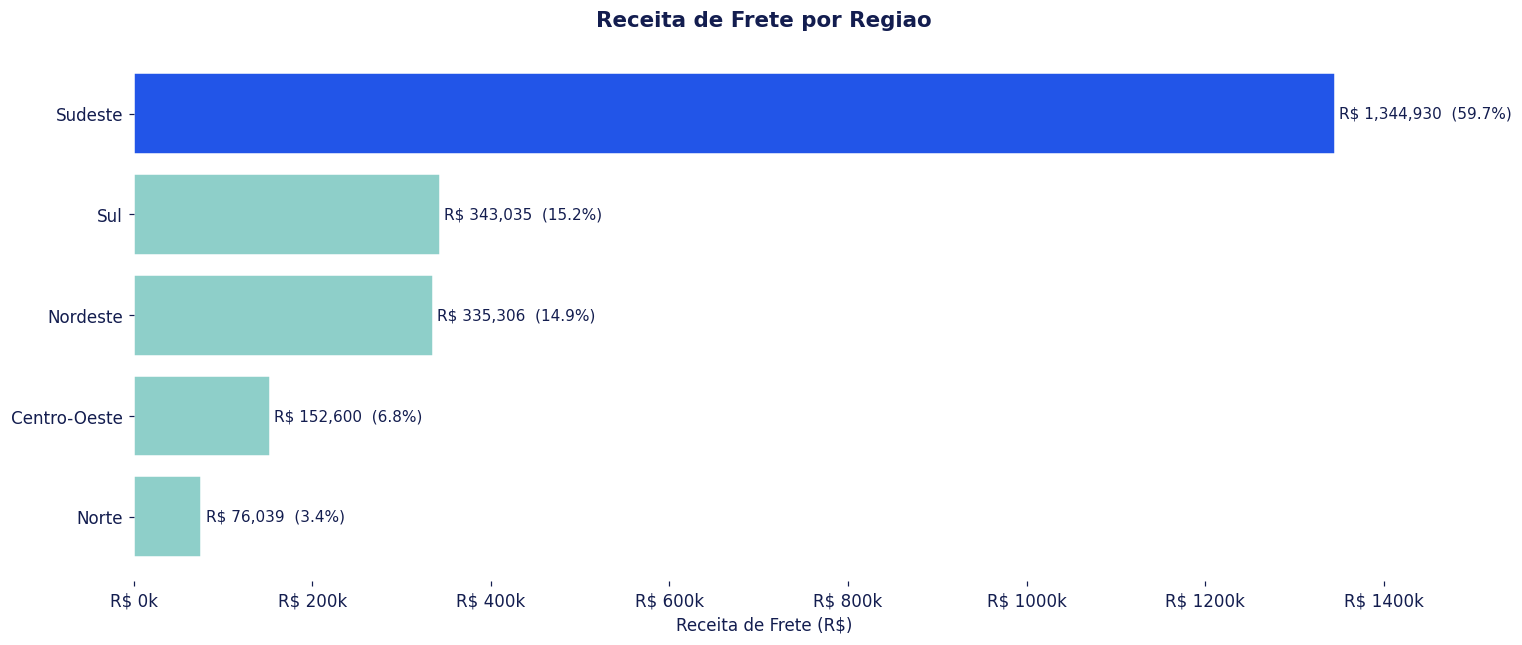

In [15]:
regioes_map = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte',
    'RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste',
    'PB':'Nordeste','PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul'
}

df_frete = base.drop_duplicates(subset=['order_id','order_item_id']).copy()
df_frete['regiao'] = df_frete['customer_state'].map(regioes_map)

frete_regiao = (
    df_frete.groupby('regiao')
    .agg(pedidos=('order_id','nunique'),
         receita_frete=('freight_value','sum'),
         frete_medio=('freight_value','mean'))
    .reset_index().sort_values('receita_frete', ascending=False)
)
total_frete = frete_regiao['receita_frete'].sum()
frete_regiao['pct_frete'] = frete_regiao['receita_frete'] / total_frete * 100

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

regioes_ord = frete_regiao.sort_values('receita_frete', ascending=True)
cores = [AZUL if r == regioes_ord['regiao'].iloc[-1] else MENTA for r in regioes_ord['regiao']]

bars = ax.barh(regioes_ord['regiao'], regioes_ord['receita_frete'],
               color=cores, edgecolor='white')
for bar, (_, row) in zip(bars, regioes_ord.iterrows()):
    ax.text(bar.get_width()+5000, bar.get_y()+bar.get_height()/2,
            f"R$ {row['receita_frete']:,.0f}  ({row['pct_frete']:.1f}%)",
            va='center', fontsize=10, color=AZUL_DARK)

ax.set_title('Receita de Frete por Regiao', fontsize=14, fontweight='bold', color=AZUL_DARK, pad=15)
ax.set_xlabel('Receita de Frete (R$)', color=AZUL_DARK)
ax.tick_params(colors=AZUL_DARK)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'R$ {v/1e3:.0f}k'))
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

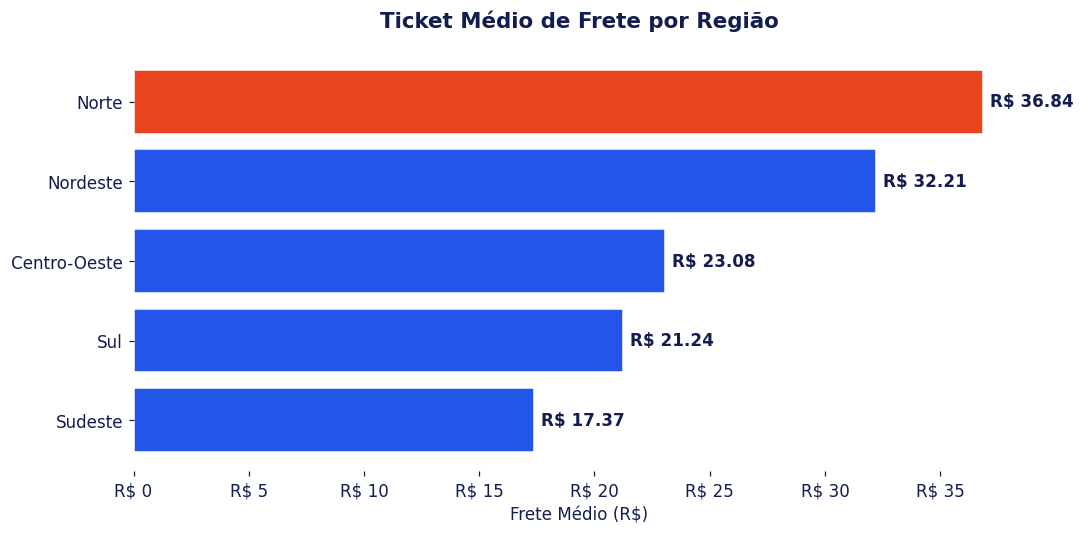

      regiao  pedidos  frete_medio  pct_frete
     Sudeste    67706    17.373444  59.723999
         Sul    14042    21.239222  15.233058
    Nordeste     9336    32.213065  14.889843
Centro-Oeste     5744    23.075751   6.776468
       Norte     1838    36.840451   3.376632


In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ord_ticket = frete_regiao.sort_values('frete_medio', ascending=True)
cores_t = [VERMELHO if r == ord_ticket['regiao'].iloc[-1] else AZUL for r in ord_ticket['regiao']]

bars = ax.barh(ord_ticket['regiao'], ord_ticket['frete_medio'],
               color=cores_t, edgecolor='white')

for bar, (_, row) in zip(bars, ord_ticket.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"R$ {row['frete_medio']:.2f}",
            va='center', fontsize=11, fontweight='bold', color=AZUL_DARK)

ax.set_title('Ticket Médio de Frete por Região', fontsize=14, fontweight='bold', color=AZUL_DARK, pad=15)
ax.set_xlabel('Frete Médio (R$)', color=AZUL_DARK)
ax.tick_params(colors=AZUL_DARK)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'R$ {v:.0f}'))
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

print(frete_regiao[['regiao','pedidos','frete_medio','pct_frete']].to_string(index=False))

In [37]:
ticket_estado = (
    df_frete.groupby('customer_state')
    .agg(
        pedidos      = ('order_id',       'nunique'),
        frete_medio  = ('freight_value',  'mean'),
        receita_frete= ('freight_value',  'sum')
    )
    .reset_index()
    .sort_values('frete_medio', ascending=False)
    .reset_index(drop=True)
)
ticket_estado.index += 1

fmt = ticket_estado.copy()
fmt['frete_medio']   = fmt['frete_medio'].apply(lambda x: f'R$ {x:.2f}')
fmt['receita_frete'] = fmt['receita_frete'].apply(lambda x: f'R$ {x:,.0f}')
fmt['pedidos']       = fmt['pedidos'].apply(lambda x: f'{x:,}')
fmt.columns = ['Estado', 'Pedidos', 'Frete Médio', 'Receita Total Frete']

pd.set_option('display.max_rows', None)
display(fmt)
pd.reset_option('display.max_rows')

,Estado,Pedidos,Frete Médio,Receita Total Frete
1,RR,46,R$ 42.98,"R$ 2,235"
2,PB,532,R$ 42.72,"R$ 25,720"
3,RO,247,R$ 41.07,"R$ 11,417"
4,AC,81,R$ 40.07,"R$ 3,687"
5,PI,493,R$ 39.15,"R$ 21,218"
6,MA,740,R$ 38.26,"R$ 31,524"
7,TO,279,R$ 37.25,"R$ 11,733"
8,SE,345,R$ 36.65,"R$ 14,111"
9,AL,411,R$ 35.84,"R$ 15,915"
10,PA,970,R$ 35.83,"R$ 38,699"


## Crescimento da receita ano a ano

In [16]:
# Garante que a coluna de data está em datetime
base['order_purchase_timestamp'] = pd.to_datetime(base['order_purchase_timestamp'])

# Cria colunas de ano e mês
base['ano']     = base['order_purchase_timestamp'].dt.year
base['mes']     = base['order_purchase_timestamp'].dt.month
base['ano_mes'] = base['order_purchase_timestamp'].dt.to_period('M')

# Agora roda o YoY
yoy = (
    base.drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('ano')
    .agg(
        pedidos = ('order_id',      'nunique'),
        receita = ('price',         'sum'),
        frete   = ('freight_value', 'sum')
    )
    .reset_index()
)
yoy['receita_total']   = yoy['receita'] + yoy['frete']
yoy['crescimento_ped'] = yoy['pedidos'].pct_change() * 100
yoy['crescimento_rec'] = yoy['receita'].pct_change() * 100

fmt = yoy.copy()
fmt['receita']       = fmt['receita'].apply(lambda x: f'R$ {x:,.0f}')
fmt['frete']         = fmt['frete'].apply(lambda x: f'R$ {x:,.0f}')
fmt['receita_total'] = fmt['receita_total'].apply(lambda x: f'R$ {x:,.0f}')
fmt['crescimento_ped'] = fmt['crescimento_ped'].apply(
    lambda x: f'+{x:.1f}%' if x > 0 else f'{x:.1f}%' if not pd.isna(x) else '-')
fmt['crescimento_rec'] = fmt['crescimento_rec'].apply(
    lambda x: f'+{x:.1f}%' if x > 0 else f'{x:.1f}%' if not pd.isna(x) else '-')

fmt.columns = ['Ano','Pedidos','Receita Produto','Receita Frete',
               'Receita Total','Cresc. Pedidos','Cresc. Receita']
display(fmt)

,Ano,Pedidos,Receita Produto,Receita Frete,Receita Total,Cresc. Pedidos,Cresc. Receita
0,2016,312,"R$ 49,786","R$ 7,397","R$ 57,183",-,-
1,2017,44579,"R$ 6,155,807","R$ 986,865","R$ 7,142,672",+14188.1%,+12264.6%
2,2018,53775,"R$ 7,386,051","R$ 1,257,647","R$ 8,643,698",+20.6%,+20.0%


In [17]:
yoy = (
    base.drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('ano')
    .agg(
        pedidos = ('order_id',  'nunique'),
        receita = ('price',     'sum'),
        frete   = ('freight_value', 'sum')
    )
    .reset_index()
)
yoy['receita_total']    = yoy['receita'] + yoy['frete']
yoy['crescimento_ped']  = yoy['pedidos'].pct_change() * 100
yoy['crescimento_rec']  = yoy['receita'].pct_change() * 100

fmt = yoy.copy()
fmt['receita']       = fmt['receita'].apply(lambda x: f'R$ {x:,.0f}')
fmt['frete']         = fmt['frete'].apply(lambda x: f'R$ {x:,.0f}')
fmt['receita_total'] = fmt['receita_total'].apply(lambda x: f'R$ {x:,.0f}')
fmt['crescimento_ped'] = fmt['crescimento_ped'].apply(
    lambda x: f'+{x:.1f}%' if x > 0 else f'{x:.1f}%' if not pd.isna(x) else '-')
fmt['crescimento_rec'] = fmt['crescimento_rec'].apply(
    lambda x: f'+{x:.1f}%' if x > 0 else f'{x:.1f}%' if not pd.isna(x) else '-')

fmt.columns = ['Ano','Pedidos','Receita Produto','Receita Frete',
               'Receita Total','Cresc. Pedidos','Cresc. Receita']
display(fmt)

,Ano,Pedidos,Receita Produto,Receita Frete,Receita Total,Cresc. Pedidos,Cresc. Receita
0,2016,312,"R$ 49,786","R$ 7,397","R$ 57,183",-,-
1,2017,44579,"R$ 6,155,807","R$ 986,865","R$ 7,142,672",+14188.1%,+12264.6%
2,2018,53775,"R$ 7,386,051","R$ 1,257,647","R$ 8,643,698",+20.6%,+20.0%


## Sazonalidade do cliente

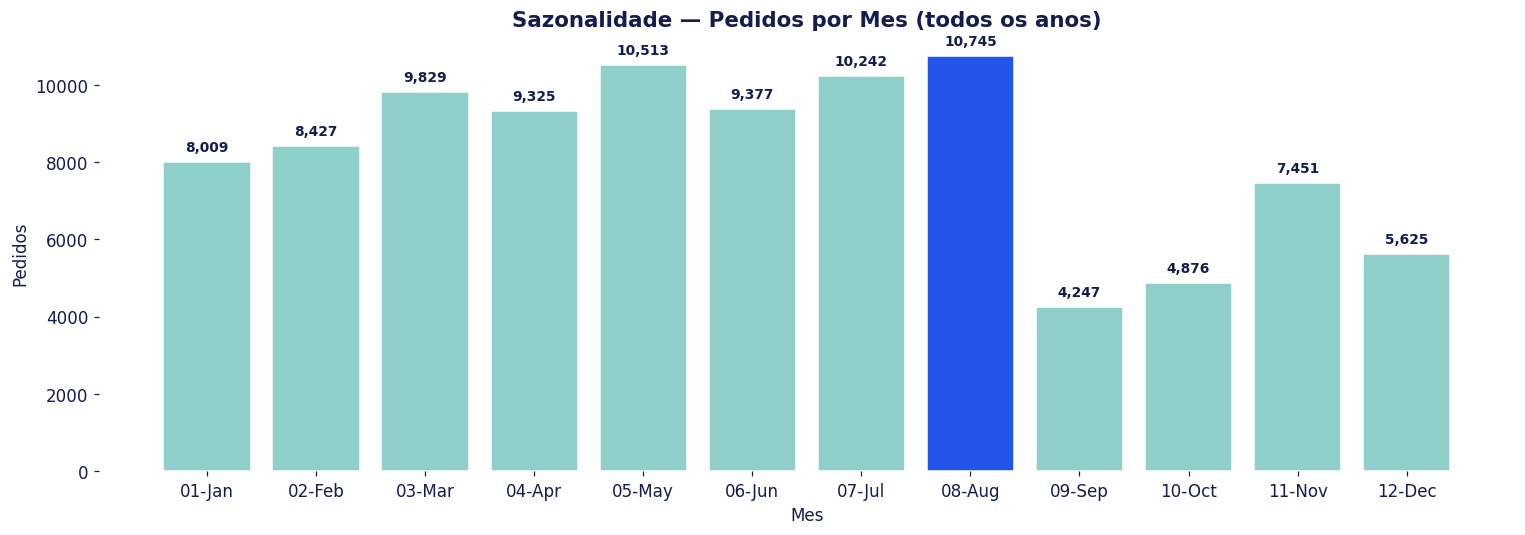

In [18]:
base['order_purchase_timestamp'] = pd.to_datetime(base['order_purchase_timestamp'])
base['mes_nome'] = base['order_purchase_timestamp'].dt.strftime('%m-%b')

sazon = (
    base.drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('mes_nome')
    .agg(
        pedidos = ('order_id', 'nunique'),
        receita = ('price',    'sum')
    )
    .reset_index()
    .sort_values('mes_nome')
)

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
cores = [AZUL if p == sazon['pedidos'].max() else MENTA for p in sazon['pedidos']]
ax.bar(sazon['mes_nome'], sazon['pedidos'], color=cores, edgecolor='white')

# Rótulos em cima de cada barra
for i, v in enumerate(sazon['pedidos']):
    ax.text(i, v + 200, f'{v:,}', ha='center', va='bottom',
            fontsize=9, color=AZUL_DARK, fontweight='bold')

ax.set_title('Sazonalidade — Pedidos por Mes (todos os anos)',
             fontsize=14, fontweight='bold', color=AZUL_DARK)
ax.set_xlabel('Mes', color=AZUL_DARK)
ax.set_ylabel('Pedidos', color=AZUL_DARK)
ax.tick_params(colors=AZUL_DARK)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

## Taxa de Recompra

In [19]:
recompra = (
    base.drop_duplicates(subset=['order_id'])
    .groupby('customer_unique_id')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'qtd_pedidos'})
)

resumo = recompra['qtd_pedidos'].value_counts().sort_index().reset_index()
resumo.columns = ['Num Pedidos', 'Qtd Clientes']
resumo['pct'] = resumo['Qtd Clientes'] / resumo['Qtd Clientes'].sum() * 100
resumo['pct'] = resumo['pct'].apply(lambda x: f'{x:.1f}%')

display(resumo)
print(f"\nClientes com 1 pedido  : {(recompra['qtd_pedidos']==1).sum():,}")
print(f"Clientes com 2+ pedidos: {(recompra['qtd_pedidos']>1).sum():,}")
print(f"Taxa de recompra       : {(recompra['qtd_pedidos']>1).mean()*100:.1f}%")

,Num Pedidos,Qtd Clientes,pct
0,1,92507,96.9%
1,2,2673,2.8%
2,3,192,0.2%
3,4,29,0.0%
4,5,9,0.0%
5,6,5,0.0%
6,7,3,0.0%
7,9,1,0.0%
8,16,1,0.0%



Clientes com 1 pedido  : 92,507
Clientes com 2+ pedidos: 2,913
Taxa de recompra       : 3.1%


## Clientes com recompra por estado

In [20]:
# Identifica clientes com recompra
recompra_ids = recompra[recompra['qtd_pedidos'] > 1]['customer_unique_id']

# Cruza com a base para pegar o estado
recompra_estado = (
    base[base['customer_unique_id'].isin(recompra_ids)]
    .drop_duplicates(subset='customer_unique_id')
    .groupby('customer_state')['customer_unique_id']
    .count()
    .reset_index()
    .sort_values('customer_unique_id', ascending=False)
    .reset_index(drop=True)
)
recompra_estado.index += 1

total_recompra = recompra_estado['customer_unique_id'].sum()
recompra_estado['pct'] = recompra_estado['customer_unique_id'] / total_recompra * 100

fmt = recompra_estado.copy()
fmt['pct'] = fmt['pct'].apply(lambda x: f'{x:.1f}%')
fmt.columns = ['Estado', 'Clientes que Recompraram', '% do Total']
display(fmt)
print(f"\nTotal de clientes com recompra: {total_recompra:,}")

,Estado,Clientes que Recompraram,% do Total
1,SP,1264,43.4%
2,RJ,417,14.3%
3,MG,336,11.5%
4,RS,162,5.6%
5,PR,142,4.9%
...,...,...,...
23,TO,7,0.2%
24,AC,4,0.1%
25,AM,3,0.1%
26,AP,1,0.0%



Total de clientes com recompra: 2,913


## Novos clientes

In [21]:
base['ano_mes'] = base['order_purchase_timestamp'].dt.to_period('M')

primeiro_pedido = (
    base.sort_values('order_purchase_timestamp')
    .drop_duplicates(subset='customer_unique_id', keep='first')
    .groupby('ano_mes')['customer_unique_id']
    .count()
    .reset_index()
    .sort_values('ano_mes')
)
primeiro_pedido.columns = ['Mes', 'Novos Clientes']
primeiro_pedido['Acumulado'] = primeiro_pedido['Novos Clientes'].cumsum()
primeiro_pedido['Mes'] = primeiro_pedido['Mes'].astype(str)

display(primeiro_pedido)
print(f"\nTotal de clientes unicos: {primeiro_pedido['Novos Clientes'].sum():,}")

,Mes,Novos Clientes,Acumulado
0,2016-09,3,3
1,2016-10,305,308
2,2016-12,1,309
3,2017-01,754,1063
4,2017-02,1705,2768
...,...,...,...
18,2018-04,6709,70590
19,2018-05,6604,77194
20,2018-06,5934,83128
21,2018-07,6054,89182



Total de clientes unicos: 95,420


## Concentração Gráfica por estado

In [22]:
geo_cli = (
    base.drop_duplicates(subset='customer_unique_id')
    .groupby('customer_state')['customer_unique_id']
    .count()
    .reset_index()
    .sort_values('customer_unique_id', ascending=False)
)
total = geo_cli['customer_unique_id'].sum()
geo_cli['pct']       = geo_cli['customer_unique_id'] / total * 100
geo_cli['acumulado'] = geo_cli['pct'].cumsum()

fmt = geo_cli.copy()
fmt['pct']       = fmt['pct'].apply(lambda x: f'{x:.1f}%')
fmt['acumulado'] = fmt['acumulado'].apply(lambda x: f'{x:.1f}%')
fmt.columns = ['Estado','Clientes Unicos','% do Total','% Acumulado']
display(fmt)

,Estado,Clientes Unicos,% do Total,% Acumulado
25,SP,39972,41.9%,41.9%
18,RJ,12300,12.9%,54.8%
10,MG,11175,11.7%,66.5%
22,RS,5247,5.5%,72.0%
17,PR,4838,5.1%,77.1%
...,...,...,...,...
20,RO,235,0.2%,99.7%
2,AM,142,0.1%,99.8%
0,AC,77,0.1%,99.9%
3,AP,67,0.1%,100.0%


In [23]:
# Instala geopandas
!pip install geopandas --quiet

import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap

# Baixa o shapefile do Brasil
url_br = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
brasil = gpd.read_file(url_br)

# Prepara os dados de clientes por estado
geo_cli['pct_num'] = geo_cli['customer_unique_id'] / geo_cli['customer_unique_id'].sum() * 100

# Merge com o shapefile
brasil['sigla'] = brasil['sigla'].str.strip().str.upper()
mapa = brasil.merge(geo_cli, left_on='sigla', right_on='customer_state', how='left')

print(f"Mapa criado: {len(mapa)} estados")
print(f"Colunas disponíveis: {brasil.columns.tolist()}")

Mapa criado: 27 estados
Colunas disponíveis: ['id', 'name', 'sigla', 'regiao_id', 'codigo_ibg', 'cartodb_id', 'created_at', 'updated_at', 'geometry']


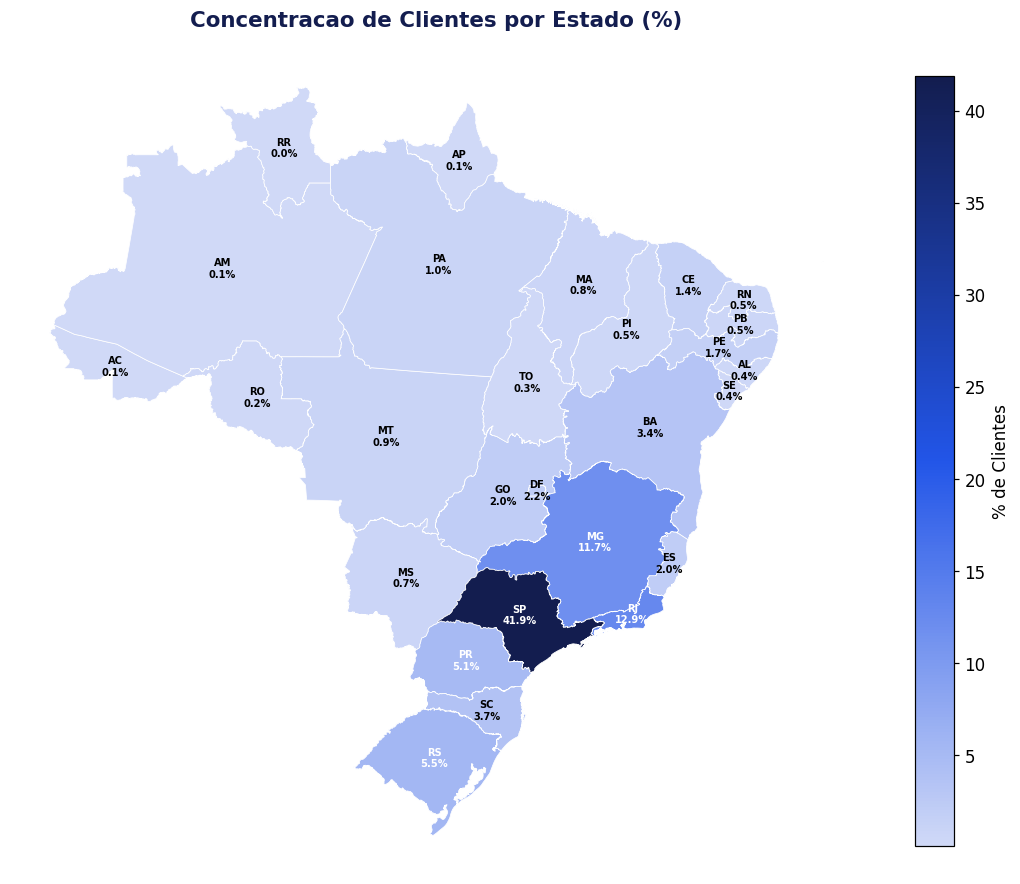

In [24]:
from matplotlib.colors import LinearSegmentedColormap

# Paleta azul mais intensa (do claro ao azul escuro Olist)
cmap_olist = LinearSegmentedColormap.from_list(
    'olist_blue', ['#d0d9f7', '#2255E8', '#131D4F']
)

fig, ax = plt.subplots(figsize=(10, 12))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

mapa.plot(
    column='pct_num',
    ax=ax,
    cmap=cmap_olist,
    edgecolor='white',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label': '% de Clientes', 'shrink': 0.6}
)

for _, row in mapa.iterrows():
    if pd.notna(row['pct_num']):
        centroid = row['geometry'].centroid
        # Texto branco em estados escuros, preto nos claros
        cor_texto = 'white' if row['pct_num'] > 5 else 'black'
        ax.text(
            centroid.x, centroid.y,
            f"{row['sigla']}\n{row['pct_num']:.1f}%",
            ha='center', va='center',
            fontsize=6.5, color=cor_texto, fontweight='bold'
        )

ax.set_title('Concentracao de Clientes por Estado (%)',
             fontsize=14, fontweight='bold', color=AZUL_DARK, pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

## Tempo médio de entrega por estado

In [25]:
base['order_purchase_timestamp']      = pd.to_datetime(base['order_purchase_timestamp'])
base['order_delivered_customer_date'] = pd.to_datetime(base['order_delivered_customer_date'])

entrega_estado = (
    base[base['order_status'] == 'delivered']
    .drop_duplicates(subset='order_id')
    .assign(dias_entrega=lambda x: (
        x['order_delivered_customer_date'] - x['order_purchase_timestamp']
    ).dt.days)
    .groupby('customer_state')['dias_entrega']
    .mean()
    .reset_index()
    .sort_values('dias_entrega', ascending=False)
)
entrega_estado.columns = ['Estado', 'Dias Medio Entrega']
entrega_estado['Dias Medio Entrega'] = entrega_estado['Dias Medio Entrega'].apply(
    lambda x: f'{x:.1f} dias')

pd.set_option('display.max_rows', None)
display(entrega_estado)
pd.reset_option('display.max_rows')

,Estado,Dias Medio Entrega
21,RR,29.0 dias
3,AP,26.7 dias
2,AM,26.0 dias
1,AL,24.0 dias
13,PA,23.3 dias
9,MA,21.1 dias
24,SE,21.0 dias
5,CE,20.8 dias
0,AC,20.6 dias
14,PB,20.0 dias


## Taxa de atraso por estado

In [26]:
base['order_estimated_delivery_date'] = pd.to_datetime(base['order_estimated_delivery_date'])

atraso = (
    base[base['order_status'] == 'delivered']
    .drop_duplicates(subset='order_id')
    .assign(atrasado=lambda x: (
        x['order_delivered_customer_date'] > x['order_estimated_delivery_date']
    ))
    .groupby('customer_state')
    .agg(
        total_pedidos = ('order_id',  'count'),
        atrasados     = ('atrasado',  'sum')
    )
    .reset_index()
)
atraso['taxa_atraso'] = atraso['atrasados'] / atraso['total_pedidos'] * 100
atraso = atraso.sort_values('taxa_atraso', ascending=False).reset_index(drop=True)

fmt = atraso.copy()
fmt['taxa_atraso'] = fmt['taxa_atraso'].apply(lambda x: f'{x:.1f}%')
fmt.columns = ['Estado','Total Pedidos','Atrasados','Taxa de Atraso']
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(fmt)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
print(f"\nTaxa de atraso geral: {atraso['atrasados'].sum()/atraso['total_pedidos'].sum()*100:.1f}%")

,Estado,Total Pedidos,Atrasados,Taxa de Atraso
0,AL,397,95,23.9%
1,MA,717,141,19.7%
2,PI,476,76,16.0%
3,CE,1279,196,15.3%
4,SE,335,51,15.2%
5,BA,3256,457,14.0%
6,RJ,12350,1664,13.5%
7,TO,274,35,12.8%
8,PA,946,117,12.4%
9,ES,1995,244,12.2%



Taxa de atraso geral: 8.1%


## Correlação entre atrasos e notas

In [27]:
df_33 = (
    base[base['order_status'] == 'delivered']
    .drop_duplicates(subset='order_id')
    .assign(
        dias_atraso=lambda x: (
            x['order_delivered_customer_date'] - x['order_estimated_delivery_date']
        ).dt.days
    )
    .assign(
        situacao=lambda x: x['dias_atraso'].apply(
            lambda d: 'Atrasado' if d > 0 else ('Em dia' if d == 0 else 'Adiantado')
        )
    )
)

resultado = (
    df_33.groupby(['review_score', 'situacao'])['order_id']
    .count()
    .unstack(fill_value=0)
    .reset_index()
)

# Garante que as 3 colunas existem mesmo que alguma situação seja zero
for col in ['Adiantado', 'Em dia', 'Atrasado']:
    if col not in resultado.columns:
        resultado[col] = 0

resultado['Total'] = resultado['Adiantado'] + resultado['Em dia'] + resultado['Atrasado']
resultado['% Atrasado']  = resultado['Atrasado']  / resultado['Total'] * 100
resultado['% Em dia']    = resultado['Em dia']     / resultado['Total'] * 100
resultado['% Adiantado'] = resultado['Adiantado']  / resultado['Total'] * 100

fmt = resultado[['review_score','Adiantado','Em dia','Atrasado','Total',
                 '% Adiantado','% Em dia','% Atrasado']].copy()

fmt['% Atrasado']  = fmt['% Atrasado'].apply(lambda x: f'{x:.1f}%')
fmt['% Em dia']    = fmt['% Em dia'].apply(lambda x: f'{x:.1f}%')
fmt['% Adiantado'] = fmt['% Adiantado'].apply(lambda x: f'{x:.1f}%')

fmt.columns = ['Nota','Adiantado','Em dia','Atrasado','Total',
               '% Adiantado','% Em dia','% Atrasado']
display(fmt)

,Nota,Adiantado,Em dia,Atrasado,Total,% Adiantado,% Em dia,% Atrasado
0,1.0,5805,110,3429,9344,62.1%,1.2%,36.7%
1,2.0,2320,50,553,2923,79.4%,1.7%,18.9%
2,3.0,7038,177,693,7908,89.0%,2.2%,8.8%
3,4.0,17947,297,649,18893,95.0%,1.6%,3.4%
4,5.0,55061,646,1057,56764,97.0%,1.1%,1.9%


In [28]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

reclamacoes = (
    base[base['review_score'] == 1]
    .drop_duplicates(subset='order_id')
    .groupby('product_category_name')
    .agg(
        qtd_reclamacoes = ('order_id', 'count'),
        nota_media      = ('review_score', 'mean')
    )
    .reset_index()
    .sort_values('qtd_reclamacoes', ascending=False)
    .reset_index(drop=True)
)
reclamacoes.index += 1

total = reclamacoes['qtd_reclamacoes'].sum()
reclamacoes['pct'] = reclamacoes['qtd_reclamacoes'] / total * 100

fmt = reclamacoes.copy()
fmt['pct'] = fmt['pct'].apply(lambda x: f'{x:.1f}%')
fmt.columns = ['Categoria','Qtd Reclamacoes','Nota Media','% do Total']
display(fmt)

print(f"\nTotal de pedidos com nota 1: {total:,}")

,Categoria,Qtd Reclamacoes,Nota Media,% do Total
1,cama_mesa_banho,1155,1.0,10.6%
2,beleza_saude,887,1.0,8.2%
3,informatica_acessorios,844,1.0,7.8%
4,moveis_decoracao,799,1.0,7.4%
5,esporte_lazer,794,1.0,7.3%
6,relogios_presentes,647,1.0,6.0%
7,utilidades_domesticas,573,1.0,5.3%
8,telefonia,480,1.0,4.4%
9,automotivo,429,1.0,4.0%
10,brinquedos,388,1.0,3.6%



Total de pedidos com nota 1: 10,854


In [29]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

cmb = (
    base[
        (base['review_score'] == 1) &
        (base['product_category_name_english'] == 'bed_bath_table')
    ]
    .drop_duplicates(subset='order_id')
    [[
        'order_id',
        'order_purchase_timestamp',
        'customer_state',
        'review_comment_title',
        'review_comment_message'
    ]]
    .dropna(subset=['review_comment_message'])
    .sort_values('order_purchase_timestamp')
    .reset_index(drop=True)
)
cmb.index += 1

display(cmb)
print(f"\nPedidos com nota 1 em cama_mesa_banho com comentario: {len(cmb):,}")

,order_id,order_purchase_timestamp,customer_state,review_comment_title,review_comment_message
1,6e5fe7366a2e1bfbf3257dba0af1267f,2016-10-09 22:36:25,PR,NaN,"Somente recebi as duas cortinas que faltaram, depois de abrir uma reckamacao junto ao Reclame Aqui. Nao indico e nao volto a comprar"
2,697705c05da5ef945de721dd31bf23c6,2017-02-03 11:31:48,SP,NaN,Serviço péssimo.
3,10dd6db4f61345e5fdaeebc10db28a72,2017-02-07 10:07:57,SP,NaN,"Só recebi uma fronha,eu comprei 2."
4,194a9f43598155086b091e0c827ad480,2017-02-12 19:08:25,ES,NaN,Não recebi meu produto! No site diz que está nós Correios pra retirada desde do dia 22/02 Mas quando vou ao correio para retirar o produto não há nenhum produto nos correios
5,d0c468c107ade3688fd4ffacea8e072b,2017-02-13 00:12:17,MG,NaN,Nao recebi o produto. Péssima empresa nao recomendo.
6,43443d5fff4b94d98df1ad41af13d302,2017-02-13 22:09:21,RJ,NaN,"Comprei 03 jogos, só foi enviado 01"
7,18f0a12f1ab339b1e6b86a163e592d58,2017-02-21 10:00:48,SP,NaN,"Recebi parte da compra o jogo de lençol.\r\nComprei um jogo americano junto , na mesma compra E NÃO RECEBI.\r\nAGUARDO PROVIDENCIAS."
8,a12c7cc529c689355b84f45a8992971d,2017-02-23 18:52:47,RJ,NaN,A cortina não é o modelo que pedi. |
9,c39c97c1d22e4a4486ce849afb668211,2017-03-01 17:24:54,SC,NaN,"Passou muito do prazo, uma falta de consideração!!!"
10,603ed359003f9966416e844105537b03,2017-03-03 16:13:44,SP,NaN,Comprei 3 jogos e so vieram 2 \r\nE agora peco dinheiro ? \r\nPaguei e quero meu produto



Pedidos com nota 1 em cama_mesa_banho com comentario: 914


## Nota média por categoria

In [30]:
nota_cat = (
    base.drop_duplicates(subset='order_id')
    .groupby('product_category_name_english')
    .agg(
        qtd_avaliacoes = ('review_score', 'count'),
        nota_media     = ('review_score', 'mean')
    )
    .reset_index()
    .sort_values('nota_media')
    .reset_index(drop=True)
)
nota_cat.index += 1

fmt = nota_cat.copy()
fmt['nota_media'] = fmt['nota_media'].apply(lambda x: f'{x:.2f}')
fmt.columns = ['Categoria','Qtd Avaliacoes','Nota Media']

pd.set_option('display.max_rows', None)
display(fmt)
pd.set_option('display.max_rows', 10)

,Categoria,Qtd Avaliacoes,Nota Media
1,security_and_services,2,2.50
2,office_furniture,1255,3.62
3,fashio_female_clothing,39,3.69
4,fashion_male_clothing,111,3.70
5,diapers_and_hygiene,27,3.74
6,furniture_mattress_and_upholstery,38,3.82
7,audio,343,3.84
8,construction_tools_safety,161,3.89
9,home_confort,373,3.89
10,fixed_telephony,214,3.90


In [31]:
nota_cat = (
    base.drop_duplicates(subset='order_id')
    .groupby('product_category_name_english')
    .agg(
        qtd_avaliacoes = ('review_score', 'count'),
        nota_media     = ('review_score', 'mean')
    )
    .reset_index()
    .sort_values('nota_media', ascending=False)  # <- maior para menor
    .reset_index(drop=True)
)
nota_cat.index += 1

fmt = nota_cat.copy()
fmt['nota_media'] = fmt['nota_media'].apply(lambda x: f'{x:.2f}')
fmt.columns = ['Categoria','Qtd Avaliacoes','Nota Media']

pd.set_option('display.max_rows', None)
display(fmt)
pd.set_option('display.max_rows', 10)

,Categoria,Qtd Avaliacoes,Nota Media
1,cds_dvds_musicals,12,4.67
2,la_cuisine,11,4.55
3,fashion_childrens_clothes,8,4.50
4,books_general_interest,505,4.47
5,costruction_tools_tools,94,4.43
6,fashion_sport,25,4.40
7,books_technical,256,4.40
8,flowers,28,4.39
9,books_imported,52,4.38
10,food_drink,223,4.38


## Distribuição por método de pagamento

In [32]:
pag = (
    base.drop_duplicates(subset='order_id')
    .groupby('payment_type')
    .agg(
        qtd_pedidos   = ('order_id',       'count'),
        valor_total   = ('payment_value',  'sum'),
        ticket_medio  = ('payment_value',  'mean')
    )
    .reset_index()
    .sort_values('qtd_pedidos', ascending=False)
)
total_ped = pag['qtd_pedidos'].sum()
pag['pct'] = pag['qtd_pedidos'] / total_ped * 100

fmt = pag.copy()
fmt['valor_total']  = fmt['valor_total'].apply(lambda x: f'R$ {x:,.0f}')
fmt['ticket_medio'] = fmt['ticket_medio'].apply(lambda x: f'R$ {x:.2f}')
fmt['pct']          = fmt['pct'].apply(lambda x: f'{x:.1f}%')
fmt.columns = ['Metodo','Qtd Pedidos','Valor Total','Ticket Medio','% do Total']
display(fmt)

,Metodo,Qtd Pedidos,Valor Total,Ticket Medio,% do Total
1,credit_card,74883,"R$ 12,314,254",R$ 164.45,75.9%
0,boleto,19614,"R$ 2,842,240",R$ 144.91,19.9%
3,voucher,2648,"R$ 213,587",R$ 80.66,2.7%
2,debit_card,1520,"R$ 215,036",R$ 141.47,1.5%


## Parcelamento médio da categoria

In [33]:
parcelas = (
    base.drop_duplicates(subset='order_id')
    .groupby('product_category_name_english')
    .agg(
        parcelas_media = ('payment_installments', 'mean'),
        ticket_medio   = ('payment_value',        'mean')
    )
    .reset_index()
    .sort_values('parcelas_media', ascending=False)
    .reset_index(drop=True)
)
parcelas.index += 1

fmt = parcelas.copy()
fmt['parcelas_media'] = fmt['parcelas_media'].apply(lambda x: f'{x:.1f}x')
fmt['ticket_medio']   = fmt['ticket_medio'].apply(lambda x: f'R$ {x:.2f}')
fmt.columns = ['Categoria','Parcelas Medias','Ticket Medio']

pd.set_option('display.max_rows', None)
display(fmt)
pd.set_option('display.max_rows', 10)

,Categoria,Parcelas Medias,Ticket Medio
1,computers,6.2x,R$ 1245.32
2,small_appliances_home_oven_and_coffee,5.5x,R$ 662.52
3,la_cuisine,4.8x,R$ 193.01
4,home_appliances_2,4.5x,R$ 521.04
5,home_confort,4.3x,R$ 178.00
6,watches_gifts,3.8x,R$ 228.75
7,kitchen_dining_laundry_garden_furniture,3.6x,R$ 234.15
8,office_furniture,3.6x,R$ 265.96
9,small_appliances,3.6x,R$ 319.64
10,bed_bath_table,3.6x,R$ 130.89


## Concentração de receita por vendedor (Top 10)

In [34]:
top_sellers = (
    base.drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('seller_id')
    .agg(
        qtd_pedidos = ('order_id',  'nunique'),
        receita     = ('price',     'sum')
    )
    .reset_index()
    .sort_values('receita', ascending=False)
    .reset_index(drop=True)
)
top_sellers.index += 1
total_rec = top_sellers['receita'].sum()
top_sellers['pct'] = top_sellers['receita'] / total_rec * 100

fmt = top_sellers.head(10).copy()
fmt['receita'] = fmt['receita'].apply(lambda x: f'R$ {x:,.0f}')
fmt['pct']     = fmt['pct'].apply(lambda x: f'{x:.1f}%')
fmt.columns = ['Vendedor','Qtd Pedidos','Receita','% do Total']
display(fmt)
print(f"\nTop 10 vendedores representam: {top_sellers.head(10)['pct'].sum():.1f}% da receita")

,Vendedor,Qtd Pedidos,Receita,% do Total
1,4869f7a5dfa277a7dca6462dcf3b52b2,1132,"R$ 229,473",1.7%
2,53243585a1d6dc2643021fd1853d8905,358,"R$ 222,776",1.6%
3,4a3ca9315b744ce9f8e9374361493884,1806,"R$ 200,473",1.5%
4,fa1c13f2614d7b5c4749cbc52fecda94,585,"R$ 194,042",1.4%
5,7c67e1448b00f6e969d365cea6b010ab,982,"R$ 187,924",1.4%
6,7e93a43ef30c4f03f38b393420bc753a,336,"R$ 176,432",1.3%
7,da8622b14eb17ae2831f4ac5b9dab84a,1314,"R$ 160,237",1.2%
8,7a67c85e85bb2ce8582c35f2203ad736,1160,"R$ 141,746",1.0%
9,1025f0e2d44d7041d6cf58b6550e0bfa,915,"R$ 138,969",1.0%
10,955fee9216a65b617aa5c0531780ce60,1287,"R$ 135,172",1.0%



Top 10 vendedores representam: 13.1% da receita


## Vendedores ativos por estado

In [35]:
vend_estado = (
    base.drop_duplicates(subset='seller_id')
    .groupby('seller_state')['seller_id']
    .count()
    .reset_index()
    .sort_values('seller_id', ascending=False)
    .reset_index(drop=True)
)
vend_estado.index += 1
vend_estado.columns = ['Estado','Qtd Vendedores']
display(vend_estado)

,Estado,Qtd Vendedores
1,SP,1849
2,PR,349
3,MG,244
4,SC,190
5,RJ,171
...,...,...
19,AM,1
20,AC,1
21,PI,1
22,MA,1
